# 05b · One geometry for all modes: joint multi-mode Euler–Bernoulli fit (Phase 2g, feeds Fig. 5)

Single-band EB fits (notebook 02a) return a different tip setback (17 / 8.7 / 7.8 / 4.3 / 7.0 µm)
and contact stiffness (k*/k 350 vs 2300–4500) for each PPP-CONTAu mode, so those numbers are not
lever constants. Here **one** lever/contact geometry is fitted to all five modes of the 1 µm map
at once. Per mode only the intrinsic damping ζₙ, an electrostatic weight εₙ, a complex gain and
(where stated) a small frequency correction δfₙ are free (`fmmpaper.jointeb`).

The ladder of models:

| model | shared | per mode | frame |
|---|---|---|---|
| M1 | α = k*/k, kcone, Q_c, setback, tip height | ζ, ε, gain | c, L free |
| **M1f** | same | ζ, ε, gain, **δf** | c, L free |
| M0f | same | ζ, ε, gain, δf | c = 0, L = 445 µm (the 2a assumption) |
| M1f-1d | same | one ζ, one ε for all modes (the old wideband fit), δf | c, L free |

The **frame** is xi = (x_stage − c)/L. The EB model sees positions only through x/L. A stage
offset c and an effective length L (in stage µm) are therefore the only frame parameters that
matter. L also absorbs a steady laser drift, because this walk ran 445 → 100 µm over 6.8 h, so
position and time are locked together. The static-shape InvOLS ruler measures c independently.

Tip mass and tip rotary inertia were tested in stage 1 and did not help (see the note at the end).
Timoshenko shear is about 0.04 % at these modes for a 2 µm lever and is not modelled.

Computation: `python tools/run_2g.py` (about 1 h), cached in `results/_cache_05b.json`.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
import json, subprocess, sys
CACHE = F.config.RESULTS_DIR / "_cache_05b.json"
if not CACHE.exists():
    subprocess.run([sys.executable, str(F.config.PROJECT_DIR / "tools" / "run_2g.py")], check=True)
C = json.loads(CACHE.read_text())
BANDS = ["CR1", "CR2", "CR3", "CR4", "CR5"]
pd.DataFrame(C["truth"]).T.assign(f_kHz=lambda d: d.f_Hz.astype(float) / 1e3).drop(columns="f_Hz")

,Q,nodes,f_kHz
CR1,115.004014,[434.0],65.008228
CR2,255.342935,"[235.0, 436.0]",201.820662
CR3,337.377183,"[159.0, 295.0]",414.076236
CR4,316.908462,"[119.0, 225.0, 330.0]",694.467460
CR5,194.210476,"[182.0, 271.5, 356.0]",1023.602407


## 1. The frame: where is the clamp in stage coordinates?

InvOLS ruler: clamp at stage -19.0 um (rms 0.8 %)
EB stage 1 (frequencies + nodes): clamp at -18.3 um (good solutions -21.8 to -15.1), L = 463.3 stage-um


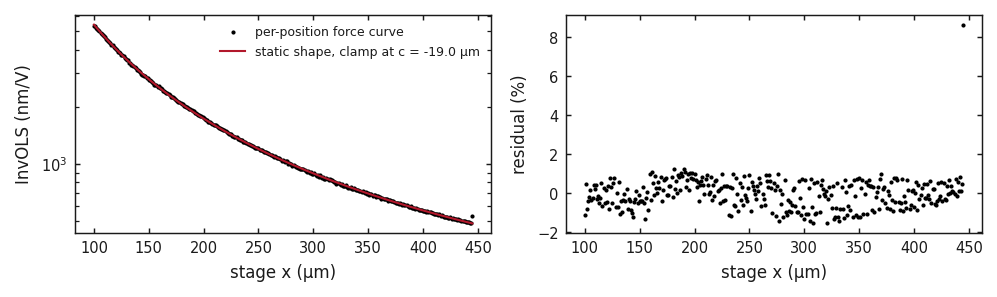

In [3]:
import re
from fmmpaper import io as _io
p = _io.path_of("ppp_dense_1um"); log = p.with_name(p.name.replace("_checkpoint.npz", "_log.txt")).read_text(errors="replace")
xs, inv = [], []
for blk in re.split(r"=== position \d+: x = ", log)[1:]:
    m = re.search(r"InvOLS ([\d.e+-]+) m/V", blk)
    if m:
        xs.append(float(blk.split()[0])); inv.append(float(m.group(1)))
xs, inv = np.array(xs), np.array(inv)
r = C["ruler_all"]; c, A = r["c_um"], r["A_um"]
u = np.clip(xs - c, 1e-3, None); shape = np.where(u <= A, u**2 * (3*A - u), 2*A**3 + (u - A) * 3*A**2)
g = np.exp(np.mean(np.log((1/inv) / shape)))
fig, axs = fp.figure("double", aspect=0.3, ncols=2)
axs[0].semilogy(xs, inv * 1e9, "k.", ms=2, label="per-position force curve")
axs[0].semilogy(xs, 1e9 / (g * shape), color=fp.C["ebgp"], lw=1, label=f"static shape, clamp at c = {c:.1f} µm")
axs[0].set_xlabel("stage x (µm)"); axs[0].set_ylabel("InvOLS (nm/V)"); axs[0].legend(fontsize=6)
axs[1].plot(xs, 100 * np.log(inv * g * shape), "k.", ms=2)
axs[1].set_xlabel("stage x (µm)"); axs[1].set_ylabel("residual (%)")
fig.tight_layout(); fp.save(fig, "05b_frame_ruler")
s1 = C["stage1"]["free_frame"]
print(f"InvOLS ruler: clamp at stage {c:.1f} um (rms {100*r['rms']:.1f} %)")
print(f"EB stage 1 (frequencies + nodes): clamp at {s1['P']['c_um']:.1f} um "
      f"(good solutions {s1['spread']['c_um'][0]:.1f} to {s1['spread']['c_um'][1]:.1f}), L = {s1['P']['L_um']:.1f} stage-um")

The ruler and the EB fit measure the clamp position from independent information: static
deflection shape vs the frequencies and nodes of five modes. They agree.

## 2. Stage 1: can one geometry place all five resonances and all twelve nodes?

In [4]:
rows = []
for lab, key in (("frame free", "free_frame"), ("2a frame (c=0, L=445)", "fixed_frame")):
    d = C["stage1"][key]
    rows.append(dict(model=lab, **{f"df_{b}_pct": v for b, v in zip(BANDS, d["freq_err_pct"])},
                     node_err_max_um=max(d["node_err_um"]), node_err_rms_um=float(np.sqrt(np.mean(np.square(d["node_err_um"])))),
                     **{k: d["P"][k] for k in ("log_alpha", "setback_um", "c_um", "L_um")}))
pd.DataFrame(rows).round(2)

,model,df_CR1_pct,df_CR2_pct,df_CR3_pct,df_CR4_pct,df_CR5_pct,node_err_max_um,node_err_rms_um,log_alpha,setback_um,c_um,L_um
0,frame free,-1.46,1.14,1.66,1.86,1.18,2.95,1.47,3.38,12.49,-18.26,463.25
1,"2a frame (c=0, L=445)",0.78,2.72,3.32,4.05,5.09,9.52,5.21,3.52,14.14,0.00,445.00


[PosixPath('/home/claude/work/paper_analysis/figures/05b_stage1_nodes.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/05b_stage1_nodes.pdf')]

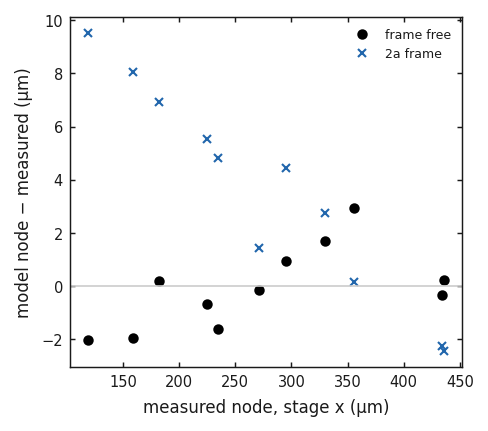

In [5]:
fig, ax = fp.figure("single", aspect=0.9)
for key, mk, col, lab in (("free_frame", "o", "k", "frame free"), ("fixed_frame", "x", fp.C["gp"], "2a frame")):
    d = C["stage1"][key]
    for j, b in enumerate(BANDS):
        tn = C["truth"][b]["nodes"]; mn = d["model_nodes"][b]
        for t in tn:
            q = min(mn, key=lambda v: abs(v - t)) if mn else np.nan
            ax.plot(t, q - t, mk, color=col, ms=4, label=lab if (j == 0 and t == tn[0]) else None)
ax.axhline(0, color="0.8", lw=0.8)
ax.set_xlabel("measured node, stage x (µm)"); ax.set_ylabel("model node − measured (µm)"); ax.legend(fontsize=6)
fp.save(fig, "05b_stage1_nodes")

## 3. Complex joint fits at N = 30 (held-out scoring), against single-band fits

In [6]:
c2a = json.loads((F.config.RESULTS_DIR / "_cache_02a.json").read_text())
lad = C["ladder"]
tab = {}
for key in ("M1f", "M0f", "M1f-1d", "M1"):
    tab[key] = {r["band"]: r["nrmse"] for r in lad[key]["score"]}
tab["single-band EB, corrected frame"] = {b: C["ind"][b]["nrmse"] for b in BANDS if b in C.get("ind", {})}
for arm in ("EB", "EB+GP", "GP", "low-rank"):
    tab[f"2a {arm} (single band, 2a frame)"] = {b: c2a[f"{b}|30"][arm]["nrmse"] for b in BANDS}
nrmse30 = pd.DataFrame(tab).T[BANDS]
nodes30 = pd.DataFrame({**{k: {r["band"]: r["node_err_um"] for r in lad[k]["score"]} for k in ("M1f", "M0f", "M1f-1d")},
                        "single-band EB, corrected frame": {b: C["ind"][b]["node_err_um"] for b in BANDS if b in C.get("ind", {})},
                        **{f"2a {a}": {b: c2a[f"{b}|30"][a]["node_err_um"] for b in BANDS} for a in ("EB", "EB+GP", "GP", "low-rank")}}).T[BANDS]
print("held-out complex NRMSE, N = 30"); display(nrmse30.round(3))
print("mean node error (um), N = 30"); display(nodes30.round(1))

held-out complex NRMSE, N = 30


,CR1,CR2,CR3,CR4,CR5
M1f,0.134,0.141,0.232,0.343,0.473
M0f,0.128,0.148,0.268,0.380,0.468
M1f-1d,0.388,0.146,0.271,0.354,0.518
M1,0.763,0.859,0.921,0.928,0.827
"single-band EB, corrected frame",0.152,0.146,0.243,0.496,0.462
"2a EB (single band, 2a frame)",0.144,0.179,0.326,0.468,0.545
"2a EB+GP (single band, 2a frame)",0.063,0.081,0.115,0.183,0.240
"2a GP (single band, 2a frame)",0.063,0.070,0.076,0.100,0.137
"2a low-rank (single band, 2a frame)",0.063,0.074,0.130,0.361,0.379


mean node error (um), N = 30


,CR1,CR2,CR3,CR4,CR5
M1f,0.0,1.0,1.5,1.7,1.2
M0f,0.0,2.0,6.5,6.7,4.2
M1f-1d,0.0,1.0,1.5,1.7,1.2
"single-band EB, corrected frame",1.0,0.0,2.0,2.7,2.8
2a EB,0.0,4.5,10.0,10.3,9.8
2a EB+GP,1.0,1.0,3.0,3.0,2.5
2a GP,1.0,2.0,0.0,0.0,1.2
2a low-rank,0.0,1.5,1.0,6.3,30.2


In [7]:
par = pd.DataFrame({k: {**{p: lad[k]["P"][p] for p in ("log_alpha", "log_kcone", "log_Qc", "setback_um", "tip_h_um", "c_um", "L_um")},
                        **{f"zeta_{b}": z for b, z in zip(BANDS, lad[k]["zeta"])},
                        **{f"dlf_{b}_pct": 100 * d for b, d in zip(BANDS, lad[k]["dlf"])}}
                    for k in ("M1f", "M0f", "M1f-1d")}).T
par["k*/k"] = 10 ** par.log_alpha
display(par.round(4))
ind = pd.DataFrame({b: {"setback_um": C["ind"][b]["theta"].get("tip_setback_um"), "k*/k": C["ind"][b]["theta"].get("k_ratio"),
                        "zeta": C["ind"][b]["theta"].get("zeta")} for b in BANDS if b in C.get("ind", {})}).T
print("single-band fits in the corrected frame (each mode its own geometry):"); display(ind.round(4))

,log_alpha,log_kcone,log_Qc,setback_um,tip_h_um,c_um,L_um,zeta_CR1,zeta_CR2,zeta_CR3,zeta_CR4,zeta_CR5,dlf_CR1_pct,dlf_CR2_pct,dlf_CR3_pct,dlf_CR4_pct,dlf_CR5_pct,k*/k
M1f,3.3827,1.9374,2.9692,12.4627,14.5910,-18.3290,463.3190,0.0048,0.0022,0.0017,0.0019,0.0042,-1.4524,1.1528,1.6700,1.8728,1.1857,2413.7655
M0f,3.4899,2.1327,1.8593,12.4957,25.0000,0.0000,445.0000,0.0049,0.0021,0.0014,0.0009,0.0001,4.0000,3.1993,3.0304,3.3358,4.0000,3089.9373
M1f-1d,3.3827,1.9418,2.9684,12.4593,14.6085,-18.3203,463.3103,0.0023,0.0023,0.0023,0.0023,0.0023,-1.4621,1.1465,1.6681,1.8675,1.1791,2413.7212


single-band fits in the corrected frame (each mode its own geometry):


,setback_um,k*/k,zeta
CR1,19.0945,324.7551,0.0046
CR2,9.0182,47281.9016,0.0021
CR3,7.0422,4598.0880,0.0015
CR4,8.7803,2207.2806,0.0023
CR5,7.1929,2340.0365,0.0015


## 4. Leave one mode out: does the geometry from four modes predict the fifth?

In [8]:
lomo = pd.DataFrame({b: dict(nrmse_heldout_mode=v["score"]["nrmse"], nrmse_all5_fit=next(r["nrmse"] for r in lad["M1f"]["score"] if r["band"] == b),
                             node_err_um=v["score"]["node_err_um"], freq_pred_from_geometry_pct=v["eig_freq_err_pct"],
                             setback_um=v["train_P"]["setback_um"], c_um=v["train_P"]["c_um"], L_um=v["train_P"]["L_um"])
                     for b, v in C["lomo"].items()}).T
lomo.round(3)

,nrmse_heldout_mode,nrmse_all5_fit,node_err_um,freq_pred_from_geometry_pct,setback_um,c_um,L_um
CR1,0.134,0.134,1.000,-2.826,10.728,-20.750,465.740
CR2,0.142,0.141,1.000,1.338,12.544,-18.680,463.670
CR3,0.230,0.232,1.000,2.036,12.790,-14.714,459.704
CR4,0.342,0.343,1.667,1.916,12.433,-18.215,463.205
CR5,0.477,0.473,1.833,1.317,12.833,-14.681,459.671


## 5. Small N: pooling five modes into one geometry

Starts use only what the design positions provide: their resonance frequencies and the InvOLS
ruler at those positions. The dense-map nodes are not used. "Joint EB+GP" adds the model-free GP
(`recon.rec_gp`) to the joint-EB residual at the design positions.

In [9]:
sm = C["smallN"]
rows = []
for n, v in sm.items():
    for r in v["score"]:
        rows += [dict(N=int(n), mode=r["band"], arm="joint EB", nrmse=r["nrmse"], node=r["node_err_um"]),
                 dict(N=int(n), mode=r["band"], arm="joint EB+GP", nrmse=r["nrmse_gp"], node=r["node_err_gp"])]
for k, v in c2a.items():
    b, n = k.split("|")
    for a in ("EB", "EB+GP", "GP", "low-rank"):
        rows.append(dict(N=int(n), mode=b, arm=f"single-band {a}", nrmse=v[a]["nrmse"], node=v[a]["node_err_um"]))
lcN = pd.DataFrame(rows)
lcN[lcN.N.isin([4, 5, 6, 8])].pivot_table(index=["mode", "N"], columns="arm", values="nrmse").round(3)

arm     joint EB  joint EB+GP  single-band EB  single-band EB+GP  \
mode N                                                             
CR1  4     0.141        0.126           0.142              0.123   
     5     0.135        0.112           0.151              0.111   
     6     0.137        0.112           0.150              0.104   
     8     0.138        0.078           0.150              0.096   
CR2  4     0.154        0.162           0.191              0.182   
     5     0.148        0.138           0.180              0.145   
     6     0.153        0.139           0.180              0.132   
     8     0.155        0.140           0.180              0.121   
CR3  4     0.267        0.271           0.345              0.332   
     5     0.252        0.214           0.326              0.278   
     6     0.247        0.202           0.318              0.231   
     8     0.250        0.200           0.356              0.218   
CR4  4     0.360        0.370           0.808              0.821   
     5     0.392        0.292           0.457              0.376   
     6     0.359        0.265           0.450              0.330   
     8     0.363        0.162           0.444              0.293   
CR5  4     0.490        0.529           0.703              0.662   
     5     0.978        0.977           1.051              0.990   
     6     0.466        0.448           0.578              0.447   
     8     0.458        0.431           0.572              0.412   

arm     single-band GP  single-band low-rank  
mode N                                        
CR1  4           0.117                 0.124  
     5           0.096                 0.082  
     6           0.094                 0.096  
     8           0.085                 0.074  
CR2  4           0.229                 0.266  
     5           0.181                 0.149  
     6           0.168                 0.130  
     8           0.103                 0.106  
CR3  4           0.966                 0.636  
     5           0.958                 0.396  
     6           0.141                 0.221  
     8           0.116                 0.168  
CR4  4           1.019                 1.049  
     5           0.959                 0.730  
     6           0.945                 0.527  
     8           0.183                 0.437  
CR5  4           0.996                 1.427  
     5           0.999                 0.925  
     6           0.971                 0.828  
     8           0.270                 0.489

[PosixPath('/home/claude/work/paper_analysis/figures/05b_smallN_joint_vs_single.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/05b_smallN_joint_vs_single.pdf')]

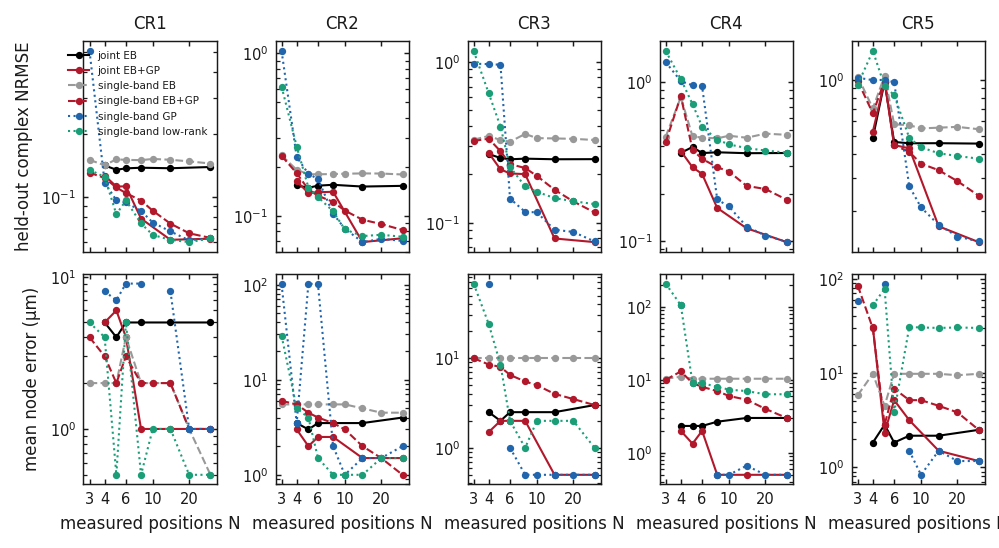

In [10]:
ARMS = {"joint EB": ("k", "-"), "joint EB+GP": (fp.C["ebgp"], "-"), "single-band EB": ("0.6", "--"),
        "single-band EB+GP": (fp.C["ebgp"], "--"), "single-band GP": (fp.C["gp"], ":"), "single-band low-rank": (fp.C["lowrank"], ":")}
fig, axs = fp.figure("double", aspect=0.55, ncols=5, nrows=2, sharex=True)
for j, b in enumerate(BANDS):
    for a, (col, ls) in ARMS.items():
        d = lcN[(lcN["mode"] == b) & (lcN.arm == a)].sort_values("N")
        axs[0, j].plot(d.N, d.nrmse, marker="o", ms=2.5, color=col, ls=ls, lw=1, label=a)
        axs[1, j].plot(d.N, np.maximum(d.node.replace(np.inf, np.nan), 0.5), marker="o", ms=2.5, color=col, ls=ls, lw=1)
    axs[0, j].set_yscale("log"); axs[1, j].set_yscale("log"); axs[0, j].set_title(b)
    fp.n_axis(axs[1, j]); axs[1, j].set_xlabel("measured positions N")
axs[0, 0].set_ylabel("held-out complex NRMSE"); axs[1, 0].set_ylabel("mean node error (µm)")
axs[0, 0].legend(fontsize=5)
fig.tight_layout(); fp.save(fig, "05b_smallN_joint_vs_single")

In [11]:
v5 = sm.get("5")
if v5:
    sel5 = recon.select_equispaced(F.load("ppp_dense_1um").x_um, 5)
    print("N = 5 design:", F.load("ppp_dense_1um").x_um[sel5], "  CR5 nodes:", C["truth"]["CR5"]["nodes"])

N = 5 design: [100. 186. 272. 359. 445.]   CR5 nodes: [182.0, 271.5, 356.0]


**The N = 5 CR5 outlier is a design effect.** The equispaced N = 5 pitch (86 µm) matches CR5's
node spacing (≈ 87 µm). Three of the five positions (186, 272, 359 µm) land on CR5 nodes (182,
271.5, 356 µm), where CR5's amplitude is 9–16 % of typical, so CR5 is effectively unobserved in
that design. This argues for a physics-aware design rule (EIG) over equispaced sampling once
several modes are targeted.

## Findings

1. **Frame.**
   - The clamp sits at stage x = −19.0 µm (InvOLS static-shape ruler, 0.8 % rms) and at
     −18.3 µm from the EB frequencies and nodes (good solutions −15 to −22 µm). These are two
     independent measurements.
   - The lever spans L = 463 stage-µm.
   - The 2a assumption (clamp at 0, L = 445 µm) is off by 19 µm and 4 %. This is what made the
     single-band setbacks mode-dependent.
2. **One geometry fits all five modes.**
   - With the frame free, one geometry places all 12 interior nodes within 3 µm (rms 1.5 µm) and
     all five resonances within −1.5 to +1.9 %. In the 2a frame the errors are 0.8–5.1 % and up to
     9.5 µm, with spurious extra nodes.
   - The complex fit at N = 30 (M1f) gives held-out NRMSE 0.134 / 0.141 / 0.232 / 0.343 / 0.473
     and nodes within 0–1.7 µm.
   - All parameters sit inside their bounds: k*/k ≈ 2400, setback 12.5 µm, tip height 14.6 µm.
   - It beats five independent single-band fits in the 2a frame on CR2–CR5 (NRMSE 0.179 / 0.326 /
     0.468 / 0.545; nodes 4.5–10 µm) with fewer parameters (22 vs ~35).
   - In the corrected frame the single-band fits come close on four modes (CR4 0.50 vs 0.34), but
     their parameters still scatter (setback 7–19 µm, k*/k 330 to 47 000). Per-band EB
     parameters are not identifiable; the joint geometry is.
3. **Damping is per mode.**
   - ζ = 0.0048 / 0.0022 / 0.0017 / 0.0019 / 0.0042 for CR1–CR5.
   - Forcing one ζ and one ε on all modes (the old wideband fit) breaks CR1 (0.39).
4. **Residual model error: frequencies vs nodes.**
   - The shared-geometry EB model cannot match frequencies to within a linewidth and nodes to
     about 1 µm at the same time.
   - The node-seeded solution (setback 12.5 µm) needs per-mode frequency corrections of −1.5 to
     +1.9 %, about 3–6 linewidths. The frequency-seeded solution (setback ≈ 8 µm, clamp −21 µm,
     L 466 µm) needs ≤ 0.2 % but misplaces nodes by 2–5 µm.
   - Without the correction the complex fit collapses (0.76–0.93).
   - Tip mass and tip rotary inertia do not remove this; Timoshenko shear is negligible.
   - Candidates, untested: non-uniform cross-section (trapezoidal section, tip-end taper, Au
     layer), frequency-dependent contact stiffness, and the measured contact frequency drifting
     along the lever (CR2 201–216 kHz, CR5 1014–1064 kHz across positions).
5. **Leave one mode out** (the held-out mode's spectra, frequency and nodes enter nowhere).
   - Geometry from four modes predicts the fifth mode's shape as well as a fit that includes it:
     NRMSE 0.134 / 0.142 / 0.230 / 0.342 / 0.477 vs 0.134 / 0.141 / 0.232 / 0.343 / 0.473.
   - Held-out nodes fall within 1.0–1.8 µm.
   - The held-out resonance is predicted to −2.8 / +1.3 / +2.0 / +1.9 / +1.3 %. The mode *shape*
     transfers; the frequency carries the ~2 % model error of finding 4.
6. **Small N: pooling five modes into one geometry.**
   - Joint EB reaches its model floor by N = 4, using starts from the design positions only.
   - At N = 4 it is the best arm on CR2–CR5: CR4 0.36 vs 0.81 for the best single-band arm; CR5
     0.49 vs 0.66; CR3 0.27 vs 0.33.
   - It places CR3–CR5 nodes within 2–3 µm, where single-band EB is ~10 µm off and GP/low-rank fail.
   - Joint EB+GP is best or equal from N ≈ 6–8 on CR3–CR5 (CR4 at N = 8: 0.16 vs GP 0.18,
     low-rank 0.44) and converges to GP at large N.
   - The one weak spot is CR1's near-tip node (434 µm): 5 µm off in the frequency-seeded solutions.
   - The N = 5 CR5 failure is design aliasing (below).

**Stage-1 checks not repeated here.**
- Tip mass: a free tip mass never beats the physical value (μ ≈ 0.0018, pyramid mass).
- Tip rotary inertia: J = 10⁻⁴ halves the CR2–CR4 frequency error but worsens the nodes, so there
  is no net gain. The physical J for a 12.5 µm pyramid is about 5×10⁻⁷.
- Package note: `activemodemap.forward_model.beam_modes` loses precision above mode 12 (modes 13–14
  have tip value 0; mode 12 has norm 1.003). `jointeb.beam_modes` uses a cancellation-free form.

In [12]:
results.save("fig5b_joint_geometry", dict(ruler=C["ruler_all"], stage1=C["stage1"], ladder=C["ladder"],
             ind=C.get("ind"), lomo=C.get("lomo"), smallN=C.get("smallN")), table=lcN)

PosixPath('/home/claude/work/paper_analysis/results/fig5b_joint_geometry.json')